In [1]:
!pip install mapclassify
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 69.6 MB/s eta 0:00:00


In [2]:
import geopandas
import pandas as pd
import folium
import matplotlib.pyplot as plt
import mapclassify
import shapely
from shapely.geometry import Point
import rasterio
import matplotlib
from matplotlib import pyplot
from rasterio.plot import show
from rasterio.plot import show_hist

<Axes: >

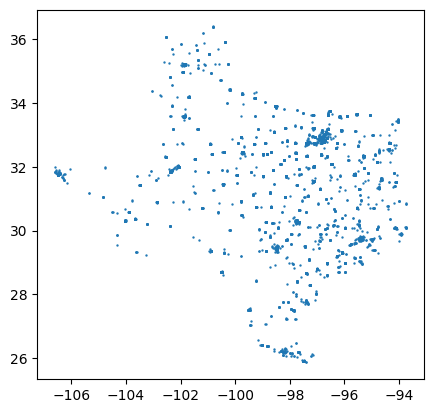

In [11]:
# Load a geojson
buildings = geopandas.read_file("/buildings.geojson")
texas_counties = geopandas.read_file("/texas_county.geojson")
buildings = buildings.to_crs("EPSG:4326")
newgdf = buildings.to_file("example.shp", driver="ESRI Shapefile")
buildings.plot(markersize=0.5)

AttributeError: 'GeoSeries' object has no attribute 'areas'

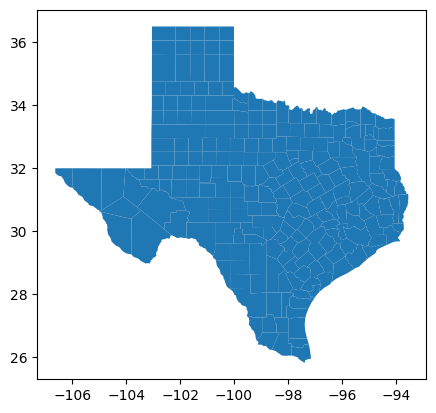

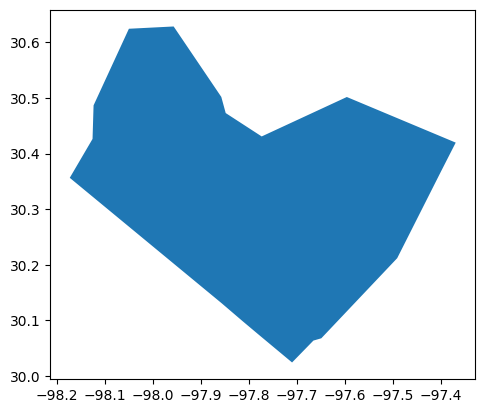

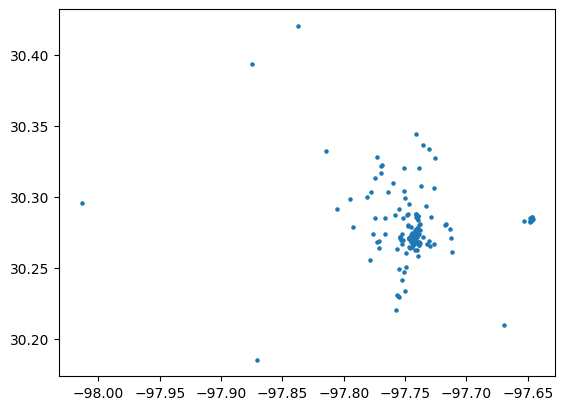

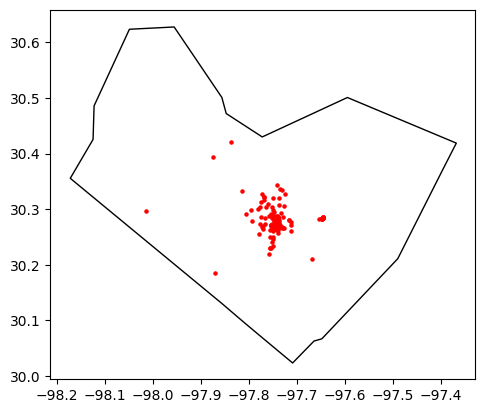

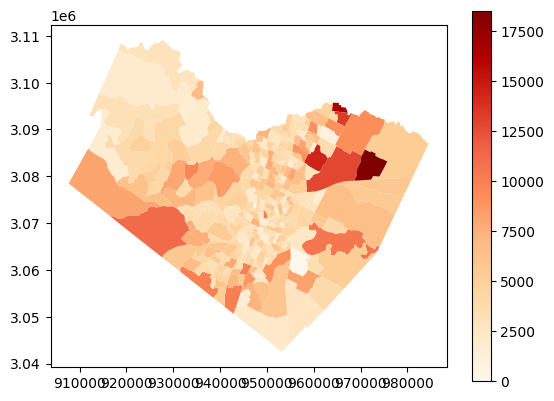

In [46]:
buildings.head
select_buildings = buildings[buildings['place_type'] == 'government building']
texas_counties = geopandas.read_file("/texas_county.geojson")
texas_counties = texas_counties.to_crs("EPSG:4326")
newcounties = texas_counties.to_file("countyexample.shp", driver="ESRI Shapefile")
texas_counties.plot()
texas_counties.head()
travis_boundary=texas_counties[texas_counties['name']=='Travis']
travis_boundary.plot()

travis_buildings = buildings.overlay(travis_boundary, how='intersection')
travis_buildings.plot(markersize=5)

base = travis_boundary.plot(color='white', edgecolor='black')
travis_buildings.plot(ax=base, markersize=5, color='red')

pop = geopandas.read_file('/travis_pop.geojson')
pop = pop.to_crs("EPSG:32139")
pop.head()
pop.rename(columns={'VALUE0': 'population'},inplace=True)
pop['population'] = pop['population'].astype(float)
pop.plot(column='population', cmap='OrRd', legend=True)

def calculate_population_density(gdf: geopandas.GeoDataFrame) ->geopandas.GeoDataFrame:
  gdf_copy = gdf.copy()
  #calculation
  area_sq_km = gdf_copy.geometry.areas / 1e6
  #calculate density
  gdf_copy[population_density] = gdf_copy['population'] / area_sq_km
  return gdf_copy
pop_with_density = calculate_population_density(pop)
pop_with_density.plot(column='calculate_population_density', cmap='OrRd', scheme= 'natural_break')
sm = rasterio.open

# New Section